# DA5400W: Assignment 3 — Customer Lifetime Value Prediction
### PCA + K-Means Clustering + Linear Regression Pipeline

**Course:** DA5400W — Foundations of Machine Learning  
**Instructor:** Dr. Arun B Ayyar, IIT Madras  
**Student Name:** _____ANKIT______________________  
**Roll Number:** ______DA25M546___________________  

---

### Background

You are a data scientist at an e-commerce company. The goal is to understand customer behaviour and **predict Customer Lifetime Value (CLV)** — the total revenue a customer is expected to generate.

You are given a dataset of **800 customers** with 8 behavioural features:

| Feature | Description |
|---|---|
| `recency_days` | Days since the customer's last purchase |
| `purchase_frequency` | Number of purchases in the last 12 months |
| `avg_basket_size_gbp` | Average order value (GBP) |
| `num_categories` | Number of distinct product categories purchased |
| `return_rate` | Fraction of orders returned |
| `discount_sensitivity` | Fraction of purchases made with a discount |
| `email_open_rate` | Fraction of marketing emails opened |
| `tenure_months` | Months since the customer registered |

**Target:** `clv_gbp` — estimated Customer Lifetime Value in GBP.

### Marks

| Section | Topic | Marks |
|---|---|---|
| Q1 | PCA — Dimensionality Reduction | 3 |
| Q2 | K-Means Clustering — Customer Segmentation | 3 |
| Q3 | Linear Regression — CLV Prediction | 3 |
| Q4 | Analysis — Interpretation | 1 |
| **Total** | | **10** |

> **Instructions:** Write your code in the empty cells. Do not modify the setup cell. Submit this notebook with all cells executed and outputs visible.


## Setup — Run this cell first, do not modify


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('customer_data.csv')
features = ['recency_days', 'purchase_frequency', 'avg_basket_size_gbp',
            'num_categories', 'return_rate', 'discount_sensitivity',
            'email_open_rate', 'tenure_months']
X_raw = df[features].copy()
y = df['clv_gbp'].copy()
print(f'Dataset: {df.shape[0]} customers, {len(features)} features')
df[features + ['clv_gbp']].describe().round(2)


Dataset: 800 customers, 8 features


,recency_days,purchase_frequency,avg_basket_size_gbp,num_categories,return_rate,discount_sensitivity,email_open_rate,tenure_months,clv_gbp
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,73.83,11.78,61.22,3.39,0.13,0.40,0.23,14.19,364.16
std,72.81,8.70,49.72,2.19,0.08,0.24,0.17,11.59,905.49
min,1.00,1.00,5.00,1.00,0.00,0.00,0.00,1.00,5.00
25%,26.67,2.00,29.55,2.00,0.08,0.21,0.09,5.00,6.24
50%,44.57,11.00,48.76,3.00,0.12,0.35,0.22,12.00,51.31
75%,88.93,18.00,73.65,4.00,0.19,0.60,0.33,21.00,176.82
max,334.78,40.00,279.78,12.00,0.36,1.00,0.76,60.00,5000.00


---
## Q1: PCA — Dimensionality Reduction (3 marks)

**[1 mark]** Standardise the 8 features using `StandardScaler`. Fit a full PCA and plot the **scree plot** (variance per component) and **cumulative explained variance**. State how many components explain at least 80% of the variance.

**[1 mark]** Reduce the data to that number of components (store as `X_pca`). Also create a **2D projection** (PC1 vs PC2) and colour the scatter plot by CLV.

**[1 mark]** Plot the **loadings** of PC1 and PC2. In one sentence each, state what customer characteristic each component captures.




8
[0.52219713 0.21549804 0.07414675 0.05630167 0.04207647 0.03250004
 0.03000803 0.02727187]
[0.52219713 0.73769517 0.81184192 0.86814359 0.91022006 0.94272009
 0.97272813 1.        ]


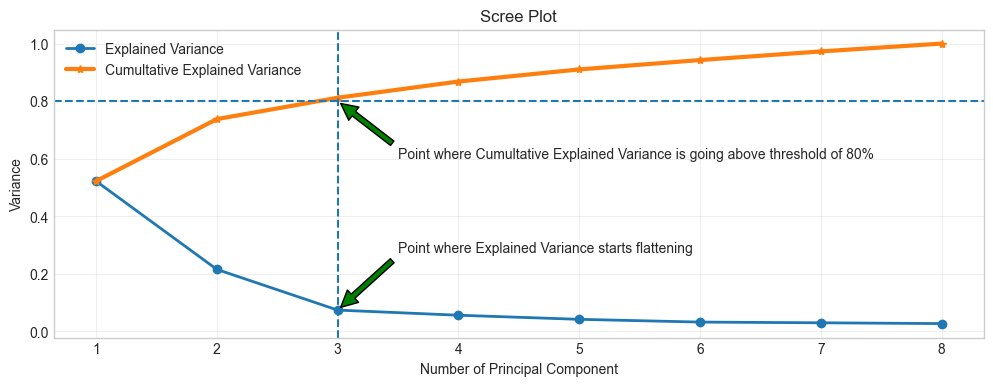

3


In [3]:
# Q1 Part 1: Standardise features, fit PCA, plot scree + cumulative variance
# Store: X_scaled, n_components
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)
#print(f"{X_scaled.shape}")

pca = PCA()
pca.fit(X_scaled)

n_components = pca.n_components_
print(f"{n_components}")

explained_variance = pca.explained_variance_ratio_
print(f"{explained_variance}")
explained_variance_cumultative = np.cumsum(explained_variance)
print(f"{explained_variance_cumultative}")

plt.figure(figsize=(12,4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', linewidth=2, label="Explained Variance")
plt.plot(range(1, len(explained_variance_cumultative)+1), explained_variance_cumultative, marker='*', linewidth=3, label="Cumultative Explained Variance")
plt.axhline(0.8, linestyle="--")
plt.axvline(3, linestyle="--")
plt.annotate(f"Point where Cumultative Explained Variance is going above threshold of 80%", xy=(3, 0.8), xytext=(3+0.5, 0.8-0.2),
             arrowprops=dict(facecolor='green', shrink=0.05))
plt.annotate(f"Point where Explained Variance starts flattening", xy=(3, explained_variance[2]), xytext=(3+0.5, explained_variance[2]+0.2),
             arrowprops=dict(facecolor='green', shrink=0.05))


plt.title("Scree Plot")
plt.xlabel("Number of Principal Component")
plt.ylabel("Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Index of the first element with value >= threshold. 
# Indices start from 0, so adding 1
n_components_80 = np.argmax(explained_variance_cumultative>=0.80)+1
print(f"{n_components_80}")
n_components = n_components_80

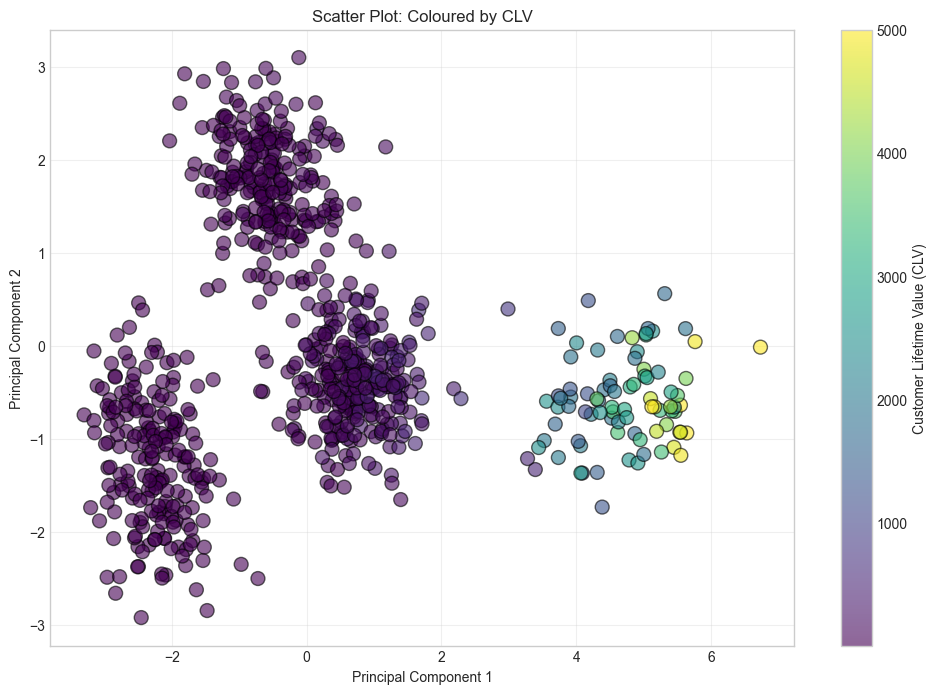

In [5]:
# Q1 Part 2: Reduce to n_components (store as X_pca)
# Also create 2D projection (store as X_pca_2d) and scatter plot coloured by CLV
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# For 2D PCA Projection, reduce PC to 2
pca=PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

clv = y

plt.figure(figsize=(12,8))

scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=clv, 
                      cmap='viridis', alpha=0.6, s=100, edgecolor='k')
plt.colorbar(scatter, label="Customer Lifetime Value (CLV)")
plt.title("Scatter Plot: Coloured by CLV")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1200x800 with 0 Axes>

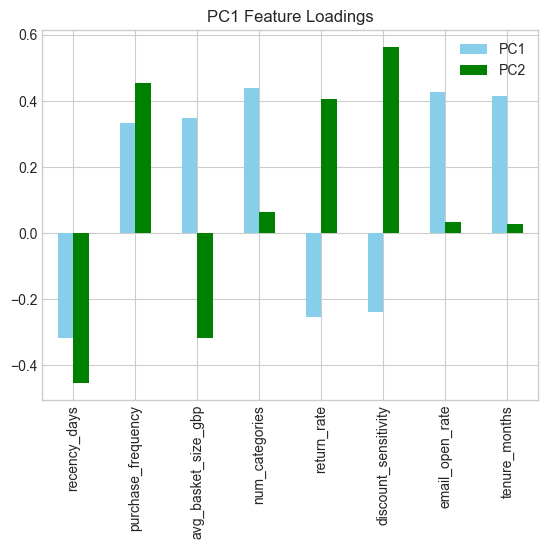

PC1 seems to capture Value and Loyalty Axis: Customers with frequent purchases, larger baskets, shop across multiple categories, respond to marketing emails, and longer tenure are strongly aligned on PC1
PC2 seems to capture Engagement with risk factors: Customers who engage across high purchase frequency, return more itms, are sensitive to discounts align on PC2.


In [5]:
# Q1 Part 3: Plot PC1 and PC2 loadings as bar charts
# Print one-sentence interpretation for each component
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features) 

# print("Feature loading:\n", loadings)

plt.figure(figsize=(12,8))

#plt.bar(features, height=loadings["PC1"], label='PC1')
#plt.bar(features, height=loadings["PC2"], label='PC2')
loadings.plot(kind='bar', color=['skyblue', 'green'])
plt.title("PC1 Feature Loadings")
plt.legend()
plt.show()

print("PC1 seems to capture Value and Loyalty Axis: " \
"Customers with frequent purchases, larger baskets, shop across multiple categories, respond to marketing emails, and longer tenure are strongly aligned on PC1")
print("PC2 seems to capture Engagement with risk factors: " \
"Customers who engage across high purchase frequency, return more itms, are sensitive to discounts align on PC2.")

---
## Q2: K-Means Clustering — Customer Segmentation (3 marks)

**[1 mark]** Run K-Means for k = 2 to 10. Plot the **elbow plot** (inertia vs k) and the **silhouette score** vs k side by side. Based on both plots, choose the best k and justify your choice in a print statement.

**[1 mark]** Fit K-Means with your chosen k on the PCA-reduced data (`X_pca`). Visualise the clusters in the PC1-PC2 space, marking each cluster's centroid with a star.

**[1 mark]** For each cluster, compute the **mean of each original feature**. Print the summary table and write one sentence describing what type of customer each cluster represents.




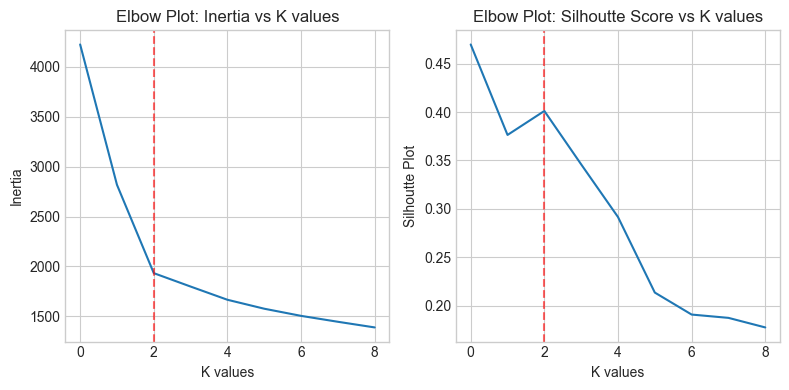

In [7]:
# Q2 Part 1: Elbow plot and silhouette score for k = 2 to 10
# Store: best_k (your chosen number of clusters)
ks = np.arange(2,10+1)

inertias = []
silhouette_scores = []

for k in ks:
    kmeans = KMeans(k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].plot(np.arange(0,len(inertias)), inertias)
axes[0].set_xlabel("K values")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Plot: Inertia vs K values")
axes[0].axvline(2, linestyle="--", alpha=0.6, color='red')
axes[1].plot(np.arange(0, len(silhouette_scores)), silhouette_scores)
axes[1].set_xlabel("K values")
axes[1].set_ylabel("Silhoutte Plot")
axes[1].set_title("Elbow Plot: Silhoutte Score vs K values")
axes[1].axvline(2, linestyle="--", alpha=0.6, color='red')

plt.tight_layout()
plt.show()

# As per graph observation
best_k = 2 


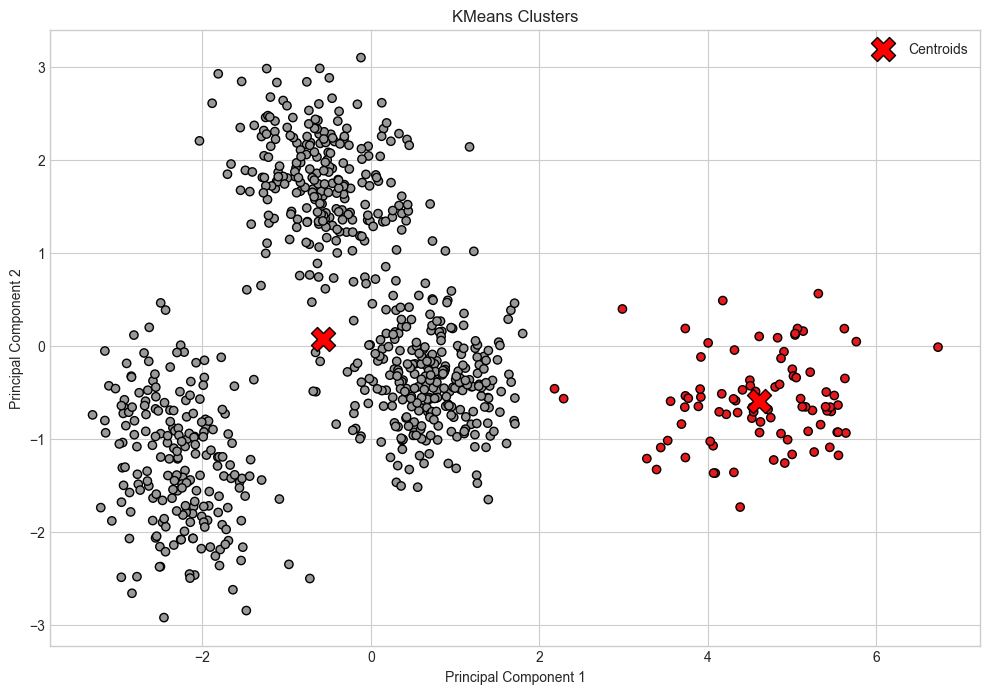

In [8]:
# Q2 Part 2: Fit K-Means with best_k, visualise clusters in PC1-PC2 space
# Store: labels (cluster assignments for all 800 customers)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca_2d)

plt.figure(figsize=(12,8))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=labels, cmap='Set1', edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], cmap='viridis', 
            marker='X', color='red', s=300, edgecolor='black', label="Centroids")
plt.title("KMeans Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()



In [9]:
# Q2 Part 3: Mean feature values per cluster — print summary table
print(f"Summary Table \n{loadings}\n")

# Write one-sentence description for each cluster
print(f"Cluster 0 (Black): Customers in this group are lower-value, less frequent shoppers, with smaller baskets and weaker engagement.")
print(f"Cluster 1 (Red): Customers here are higher-value, frequent buyers, with larger baskets, stronger engagement, and more diverse shopping behavior.")

Summary Table 
                           PC1       PC2
recency_days         -0.318620 -0.453422
purchase_frequency    0.331766  0.453178
avg_basket_size_gbp   0.348322 -0.318663
num_categories        0.438191  0.063185
return_rate          -0.253610  0.406159
discount_sensitivity -0.238238  0.562747
email_open_rate       0.427776  0.032365
tenure_months         0.413529  0.028343

Cluster 0 (Black): Customers in this group are lower-value, less frequent shoppers, with smaller baskets and weaker engagement.
Cluster 1 (Red): Customers here are higher-value, frequent buyers, with larger baskets, stronger engagement, and more diverse shopping behavior.


---
## Q3: Linear Regression — CLV Prediction (3 marks)

**[1 mark]** Split the data 80/20 (train/test, `random_state=42`). Train a `LinearRegression` model on the **raw 8 features** (baseline). Report RMSE and R-squared on the test set.

**[1 mark]** Build a combined feature matrix: **PCA components + one-hot cluster labels**. Train a second `LinearRegression` on this matrix. Report RMSE and R-squared.

**[1 mark]** Plot **predicted vs actual CLV** for both models side by side. Comment on which model performs better.

---
**Hints:**
- `train_test_split(X_raw, y, test_size=0.2, random_state=42)` to split the data
- On the predicted vs actual plot, add a red dashed diagonal (`y = x`) as the perfect prediction line


In [9]:
# Q3 Part 1: Baseline Linear Regression on raw features
# Store: X_train, X_test, y_train, y_test
# Print: RMSE and R2
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)

mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predicted)

print(f"RMSE: {rmse}, R2 Score: {r2}")



RMSE: 324.33545616526794, R2 Score: 0.8535958383718589


In [12]:
# Q3 Part 2: Linear Regression on PCA + cluster features
# Print: RMSE and R2
X_reg = np.hstack([X_pca_2d, labels.reshape(-1,1)])
print(X_pca_2d.shape)
print(labels.shape)
print(labels.reshape(-1,1).shape)
print(X_reg.shape)
# model_pca = LinearRegression()
# model_pca.fit(X_reg, y)
# y_pca_predicted = model_pca.predict(X_reg)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y, test_size=0.2, random_state=42)

model_reg = LinearRegression()
model_reg.fit(X_reg_train, y_reg_train)

y_reg_predicted = model_reg.predict(X_reg_test)

rmse_reg = np.sqrt(mean_squared_error(y_reg_test, y_reg_predicted))
r2_reg = r2_score(y_reg_test, y_reg_predicted)

print(f"RMSE: {rmse_reg}, R2 Score: {r2_reg}")

(800, 2)
(800,)
(800, 1)
(800, 3)
RMSE: 300.51906833999755, R2 Score: 0.8743077115595927


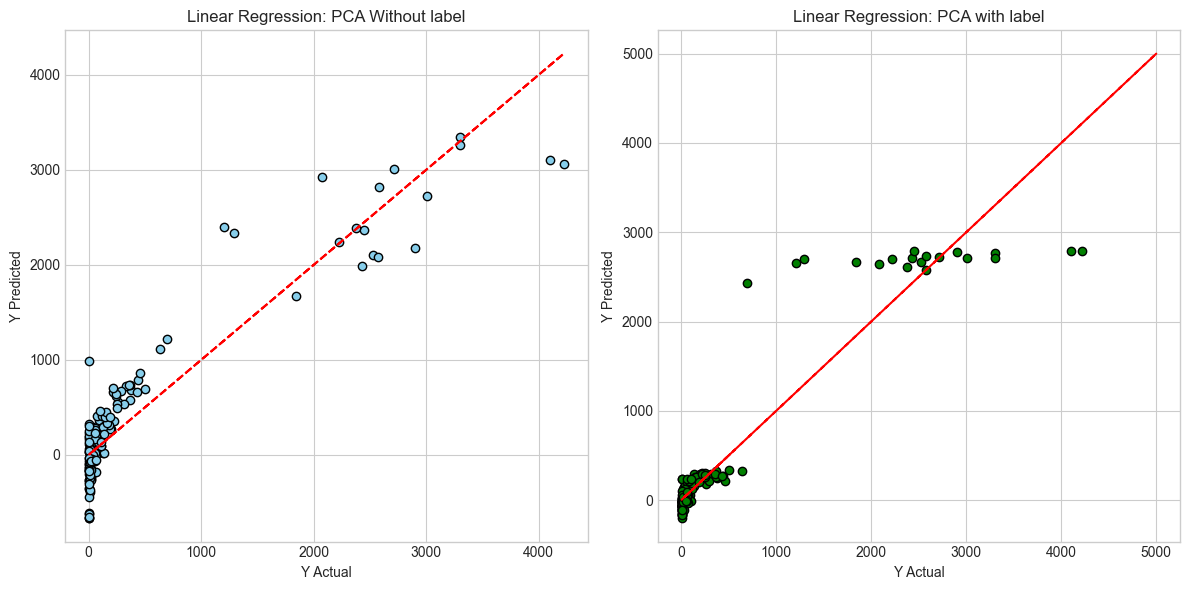

In [14]:
# Q3 Part 3: Predicted vs Actual CLV — both models side by side
_, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].scatter(y_test, y_predicted, c="skyblue", cmap='viridis', edgecolor="k")
axes[0].plot(y_test, y_test, linestyle="--", color='red')
axes[0].set_title("Linear Regression: PCA Without label")
axes[0].set_xlabel("Y Actual")
axes[0].set_ylabel("Y Predicted")
axes[1].scatter(y_reg_test, y_reg_predicted, c="green", cmap='viridis', edgecolor="k")
axes[1].plot(y, y, linestyle="--", color='red')
axes[1].set_title("Linear Regression: PCA with label")
axes[1].set_xlabel("Y Actual")
axes[1].set_ylabel("Y Predicted")

plt.tight_layout()
plt.show()

---
## Q4: Analysis (1 mark)

Answer **both** parts below in the markdown cell provided (2–4 sentences each).

**(a)** The elbow plot and silhouette score sometimes suggest different values of k. Explain what each metric measures and how you would decide between them when they disagree.

**(b)** Adding cluster labels as features improved R-squared compared to the baseline. Explain **why** knowing a customer's segment helps a linear regression model predict CLV more accurately.


### Your Answer to Q4

**(a)**     
*Looking at business context: If fine-grained segmentation - favor elbow, or clear interpretable groups is required - favor silhouette*       
*Check cluster interpretability: Do the extra clusters make sense in terms of customer behavior, or are they just statistical artifacts*        
*Stability: Multiple runs of clustering with different methods (e.g., hierarchical clustering): same 𝑘 emerges*      

**(b)**     
*Shared behavioral patterns: Customers in the same cluster tend to have similar purchasing habits, discount sensitivity, or engagement levels. CLV is often driven by these group-level behaviors.*   

*Captures heterogeneity: Linear regression assumes one global relationship between features and CLV. But in reality, different customer groups may follow different “rules.”*       
*For example: A high-frequency, low-discount cluster may have steadily high CLV. A discount-sensitive cluster may only generate CLV when promotions are frequent.*

*Cluster label as a proxy: By adding the cluster ID, you give the regression model a categorical variable that encodes these group differences. It’s like telling the model: “This customer belongs to Segment A, which typically has higher CLV than Segment B.”*

*Improved fit: The model can now adjust its predictions based on segment membership, reducing unexplained variance and boosting R².*